<a href="https://colab.research.google.com/github/minhaz-engg/Time-Series-try/blob/main/Multivariate_Forecasting_with_TSMixer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture
!pip install neuralforecast datasetsforecast

In [2]:
import pandas as pd

from datasetsforecast.long_horizon import LongHorizon

In [3]:
# Change this to your own data to try the model
Y_df, X_df, _ = LongHorizon.load(directory='./', group='ETTm2')
Y_df['ds'] = pd.to_datetime(Y_df['ds'])

# X_df contains the exogenous features, which we add to Y_df
X_df['ds'] = pd.to_datetime(X_df['ds'])
Y_df = Y_df.merge(X_df, on=['unique_id', 'ds'], how='left')

# We make validation and test splits
n_time = len(Y_df.ds.unique())
val_size = int(.2 * n_time)
test_size = int(.2 * n_time)

100%|██████████| 314M/314M [00:08<00:00, 36.2MiB/s]


In [4]:
Y_df

,unique_id,ds,y,ex_1,ex_2,ex_3,ex_4
0,HUFL,2016-07-01 00:00:00,-0.041413,-0.500000,0.166667,-0.500000,-0.001370
1,HUFL,2016-07-01 00:15:00,-0.185467,-0.500000,0.166667,-0.500000,-0.001370
2,HUFL,2016-07-01 00:30:00,-0.257495,-0.500000,0.166667,-0.500000,-0.001370
3,HUFL,2016-07-01 00:45:00,-0.577510,-0.500000,0.166667,-0.500000,-0.001370
4,HUFL,2016-07-01 01:00:00,-0.385501,-0.456522,0.166667,-0.500000,-0.001370
...,...,...,...,...,...,...,...
403195,OT,2018-02-20 22:45:00,-1.581325,0.456522,-0.333333,0.133333,-0.363014
403196,OT,2018-02-20 23:00:00,-1.581325,0.500000,-0.333333,0.133333,-0.363014
403197,OT,2018-02-20 23:15:00,-1.581325,0.500000,-0.333333,0.133333,-0.363014
403198,OT,2018-02-20 23:30:00,-1.562328,0.500000,-0.333333,0.133333,-0.363014


In [5]:
import logging

import torch
from neuralforecast.core import NeuralForecast
from neuralforecast.models import TSMixer, TSMixerx, NHITS, MLPMultivariate
from neuralforecast.losses.pytorch import MAE

In [6]:
logging.getLogger('pytorch_lightning').setLevel(logging.ERROR)
torch.set_float32_matmul_precision('high')

In [7]:
horizon = 96
input_size = 512
models = [
          TSMixer(h=horizon,
                input_size=input_size,
                n_series=7,
                max_steps=1000,
                val_check_steps=100,
                early_stop_patience_steps=5,
                scaler_type='identity',
                valid_loss=MAE(),
                random_seed=12345678,
                ),
          TSMixerx(h=horizon,
                input_size=input_size,
                n_series=7,
                max_steps=1000,
                val_check_steps=100,
                early_stop_patience_steps=5,
                scaler_type='identity',
                dropout=0.7,
                valid_loss=MAE(),
                random_seed=12345678,
                futr_exog_list=['ex_1', 'ex_2', 'ex_3', 'ex_4'],
                ),
          MLPMultivariate(h=horizon,
                input_size=input_size,
                n_series=7,
                max_steps=1000,
                val_check_steps=100,
                early_stop_patience_steps=5,
                scaler_type='standard',
                hidden_size=256,
                valid_loss=MAE(),
                random_seed=12345678,
                ),
           NHITS(h=horizon,
                input_size=horizon,
                max_steps=1000,
                val_check_steps=100,
                early_stop_patience_steps=5,
                scaler_type='robust',
                valid_loss=MAE(),
                random_seed=12345678,
                ),
         ]

INFO:lightning_fabric.utilities.seed:Seed set to 12345678
INFO:lightning_fabric.utilities.seed:Seed set to 12345678
INFO:lightning_fabric.utilities.seed:Seed set to 12345678
INFO:lightning_fabric.utilities.seed:Seed set to 12345678


In [8]:
%%capture
nf = NeuralForecast(
    models=models,
    freq='15min',
)

Y_hat_df = nf.cross_validation(
    df=Y_df,
    val_size=val_size,
    test_size=test_size,
    n_windows=None,
)

In [9]:
from utilsforecast.plotting import plot_series

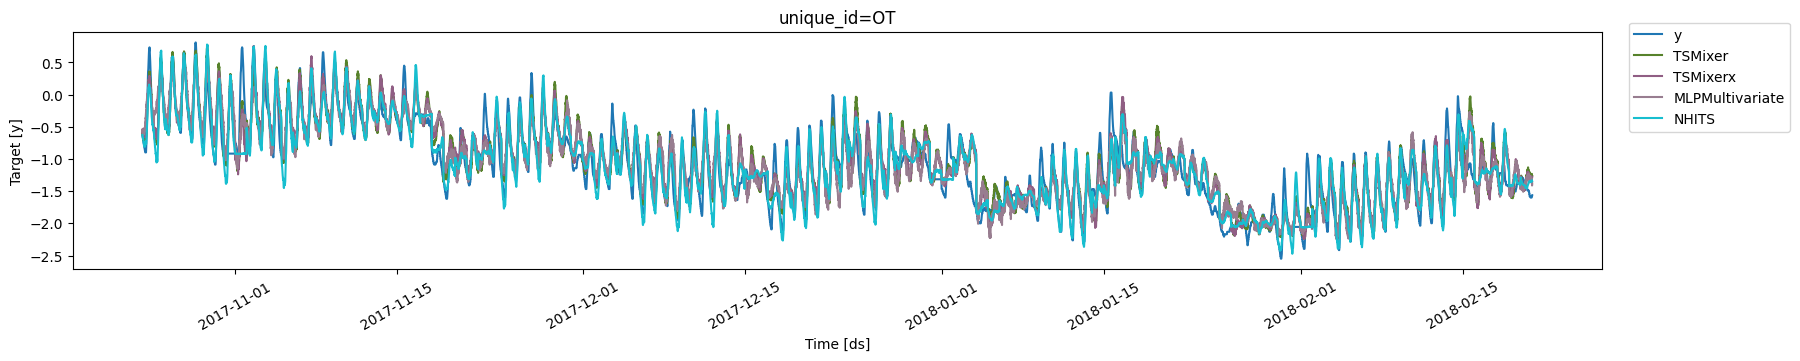

In [10]:
cutoffs = Y_hat_df['cutoff'].unique()[::horizon]
Y_plot = Y_hat_df[Y_hat_df['cutoff'].isin(cutoffs)].drop(columns='cutoff')
plot_series(forecasts_df=Y_plot, ids=['OT'])

In [11]:
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, mse

In [12]:
evaluate(Y_hat_df.drop(columns='cutoff'), metrics=[mae, mse], agg_fn='mean')

,metric,TSMixer,TSMixerx,MLPMultivariate,NHITS
0,mae,0.249067,0.254706,0.275258,0.251752
1,mse,0.163932,0.170405,0.185270,0.179504


In [13]:
from ray import tune
from ray.tune.search.hyperopt import HyperOptSearch
from neuralforecast.auto import AutoTSMixer, AutoTSMixerx

In [14]:
horizon = 96 # 24hrs = 4 * 15 min.

tsmixer_config = {
       "input_size": input_size,                                                 # Size of input window
       "max_steps": tune.choice([500, 1000, 2000]),                              # Number of training iterations
       "val_check_steps": 100,                                                   # Compute validation every x steps
       "early_stop_patience_steps": 5,                                           # Early stopping steps
       "learning_rate": tune.loguniform(1e-4, 1e-2),                             # Initial Learning rate
       "n_block": tune.choice([1, 2, 4, 6, 8]),                                  # Number of mixing layers
       "dropout": tune.uniform(0.0, 0.99),                                       # Dropout
       "ff_dim": tune.choice([32, 64, 128]),                                     # Dimension of the feature linear layer
       "scaler_type": 'identity',
    }

tsmixerx_config = tsmixer_config.copy()
tsmixerx_config['futr_exog_list'] = ['ex_1', 'ex_2', 'ex_3', 'ex_4']

In [15]:
model = AutoTSMixer(h=horizon,
                    n_series=7,
                    loss=MAE(),
                    config=tsmixer_config,
                    num_samples=10,
                    search_alg=HyperOptSearch(),
                    backend='ray',
                    valid_loss=MAE())

modelx = AutoTSMixerx(h=horizon,
                    n_series=7,
                    loss=MAE(),
                    config=tsmixerx_config,
                    num_samples=10,
                    search_alg=HyperOptSearch(),
                    backend='ray',
                    valid_loss=MAE())

In [ ]:
%%capture
nf = NeuralForecast(models=[model, modelx], freq='15min')
Y_hat_df = nf.cross_validation(df=Y_df, val_size=val_size,
                               test_size=test_size, n_windows=None)

2026-03-30 18:02:47,714	INFO worker.py:2013 -- Started a local Ray instance.
2026-03-30 18:02:50,831	INFO tune.py:253 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `Tuner(...)`.
2026-03-30 18:04:12,979	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'loss': ('__ref_ph', '0bab4678'), 'valid_loss': ('__ref_ph', 'ab9d4548')}
2026-03-30 18:05:26,113	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'loss': ('__ref_ph', '0bab4678'), 'valid_loss': ('__ref_ph', 'ab9d4548')}
2026-03-30 18:06:39,732	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'loss': ('__ref_ph', '0bab4678'), 'valid_loss': ('__ref_ph', 'ab9d4548')}
2026-03-30 18:07:36,865	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'loss': ('__ref_ph', '0bab4678'

In [ ]:
nf.models[0].results.get_best_result().config

In [ ]:
nf.models[1].results.get_best_result().config

In [ ]:
evaluate(Y_hat_df.drop(columns='cutoff'), metrics=[mae, mse], agg_fn='mean')